In [54]:
import pandas as pd
import numpy as np
from sklearn import tree
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from feature_engine.outliers import Winsorizer
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import train_test_split, GridSearchCV

import joblib
import warnings
warnings.filterwarnings("ignore")

In [20]:
dataset = pd.read_csv("clv_dataset.csv")
dataset.head()

,customer_id,age,gender,city,region,tenure_months,recency_days,frequency_orders,total_spent,avg_order_value,...,email_click_rate,loyalty_points,customer_segment,complaints,satisfaction_score,churn_risk,referral_count,avg_session_time,last_login_days,future_clv
0,1,45,Male,Bangalore,North,34,130,11,22049.35,1939.69,...,0.177,1077,Budget,0,4.7,0.126,1,16.91,116,48482.24
1,2,55,Female,Hyderabad,East,29,115,12,9864.60,930.01,...,0.081,694,Budget,0,3.1,0.178,4,11.15,57,36361.03
2,3,61,Male,Pune,South,11,195,15,27296.93,1546.24,...,0.184,999,Regular,0,3.6,0.231,1,25.61,116,46998.61
3,4,43,Female,Mumbai,Central,32,40,11,14348.10,1493.76,...,0.340,254,Budget,0,1.6,0.156,2,17.64,77,44372.90
4,5,60,Male,Mumbai,West,14,17,13,14451.23,1246.99,...,0.555,332,Budget,0,3.5,0.000,0,14.54,14,48491.85


In [21]:
x = dataset.iloc[:, :-1]
y = dataset.iloc[:, -1]

In [22]:
x.head()

,customer_id,age,gender,city,region,tenure_months,recency_days,frequency_orders,total_spent,avg_order_value,...,app_visits_per_month,email_click_rate,loyalty_points,customer_segment,complaints,satisfaction_score,churn_risk,referral_count,avg_session_time,last_login_days
0,1,45,Male,Bangalore,North,34,130,11,22049.35,1939.69,...,19,0.177,1077,Budget,0,4.7,0.126,1,16.91,116
1,2,55,Female,Hyderabad,East,29,115,12,9864.60,930.01,...,15,0.081,694,Budget,0,3.1,0.178,4,11.15,57
2,3,61,Male,Pune,South,11,195,15,27296.93,1546.24,...,16,0.184,999,Regular,0,3.6,0.231,1,25.61,116
3,4,43,Female,Mumbai,Central,32,40,11,14348.10,1493.76,...,14,0.340,254,Budget,0,1.6,0.156,2,17.64,77
4,5,60,Male,Mumbai,West,14,17,13,14451.23,1246.99,...,9,0.555,332,Budget,0,3.5,0.000,0,14.54,14


In [23]:
y.head()

0    48482.24
1    36361.03
2    46998.61
3    44372.90
4    48491.85
Name: future_clv, dtype: float64

In [24]:
numeric_feature = x.select_dtypes(exclude=["object"]).columns
catag_feature = x.select_dtypes(include=["object"]).columns

In [25]:
numeric_feature

Index(['customer_id', 'age', 'tenure_months', 'recency_days',
       'frequency_orders', 'total_spent', 'avg_order_value', 'max_order_value',
       'min_order_value', 'last_purchase_value', 'discount_usage',
       'returns_count', 'app_visits_per_month', 'email_click_rate',
       'loyalty_points', 'complaints', 'satisfaction_score', 'churn_risk',
       'referral_count', 'avg_session_time', 'last_login_days'],
      dtype='object')

In [26]:
catag_feature

Index(['gender', 'city', 'region', 'product_category', 'payment_method',
       'customer_segment'],
      dtype='object')

In [27]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("winsorizer", Winsorizer(capping_method="iqr", tail="both", fold=1.5)),
    ("scaler", MinMaxScaler())
])

In [28]:
catag_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", drop="first", sparse_output=False))
])

In [29]:
preprocess_pipeline = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_feature),
    ("catag", catag_pipeline, catag_feature)
])

In [30]:
clean = preprocess_pipeline.fit(x)

In [31]:
Clean_data = pd.DataFrame(clean.transform(x))

In [32]:
Clean_data.head()

,0,1,2,3,4,5,6,7,8,9,...,37,38,39,40,41,42,43,44,45,46
0,0.00000,0.529412,0.471429,0.354396,0.166667,0.278862,0.518775,0.305566,0.326697,0.515300,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.00001,0.725490,0.400000,0.313187,0.208333,0.112663,0.217689,0.201680,0.094926,0.147064,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,0.00002,0.843137,0.142857,0.532967,0.333333,0.350439,0.401448,0.330903,0.323162,0.417540,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
3,0.00003,0.490196,0.442857,0.107143,0.166667,0.173818,0.385799,0.526506,0.456262,0.429295,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,0.00004,0.823529,0.185714,0.043956,0.250000,0.175225,0.312212,0.427357,0.227452,0.221358,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


In [33]:
joblib.dump(clean, "decision_tree_preprocess_pipeline.pkl")

['decision_tree_preprocess_pipeline.pkl']

In [34]:
joblib.load("decision_tree_preprocess_pipeline.pkl")

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('catag', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. 

In [43]:
x_train, x_test, y_train, y_test = train_test_split(
    Clean_data, y, test_size=0.2, random_state=42
)

In [44]:
model = DecisionTreeRegressor(random_state=42)

In [45]:
params = {
    "max_depth": [3, 5, 7, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

In [46]:
grid_dt = GridSearchCV(
    estimator=model,
    param_grid=params,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

In [47]:
grid_dt.fit(x_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeR...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [3, 5, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 :

In [48]:
best_dt = grid_dt.best_estimator_
print(best_dt)

DecisionTreeRegressor(max_depth=10, min_samples_leaf=4, min_samples_split=10,
                      random_state=42)


In [49]:
y_train_pred = grid_dt.predict(x_train)
y_test_pred = grid_dt.predict(x_test)

In [50]:
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

print("Training R2 Score:", train_r2)
print("Testing R2 Score:", test_r2)

Training R2 Score: 0.8546066860671566
Testing R2 Score: 0.8217697972786102


In [51]:
train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)
print("Training Mean squared error: ", train_mse)
print("Testing Mean squared error: ", test_mse)

Training Mean squared error:  96400448.3722172
Testing Mean squared error:  120618220.32505298


In [52]:
train_rmse = np.sqrt(train_mse)
test_rmse = np.sqrt(test_mse)
print("Training Root mean squared error: ", train_rmse)
print("Testing Root mean squared error: ", test_rmse)

Training Root mean squared error:  9818.373000259116
Testing Root mean squared error:  10982.632668219992


In [53]:
joblib.dump(grid_dt, "decision_tree.pkl")

['decision_tree.pkl']

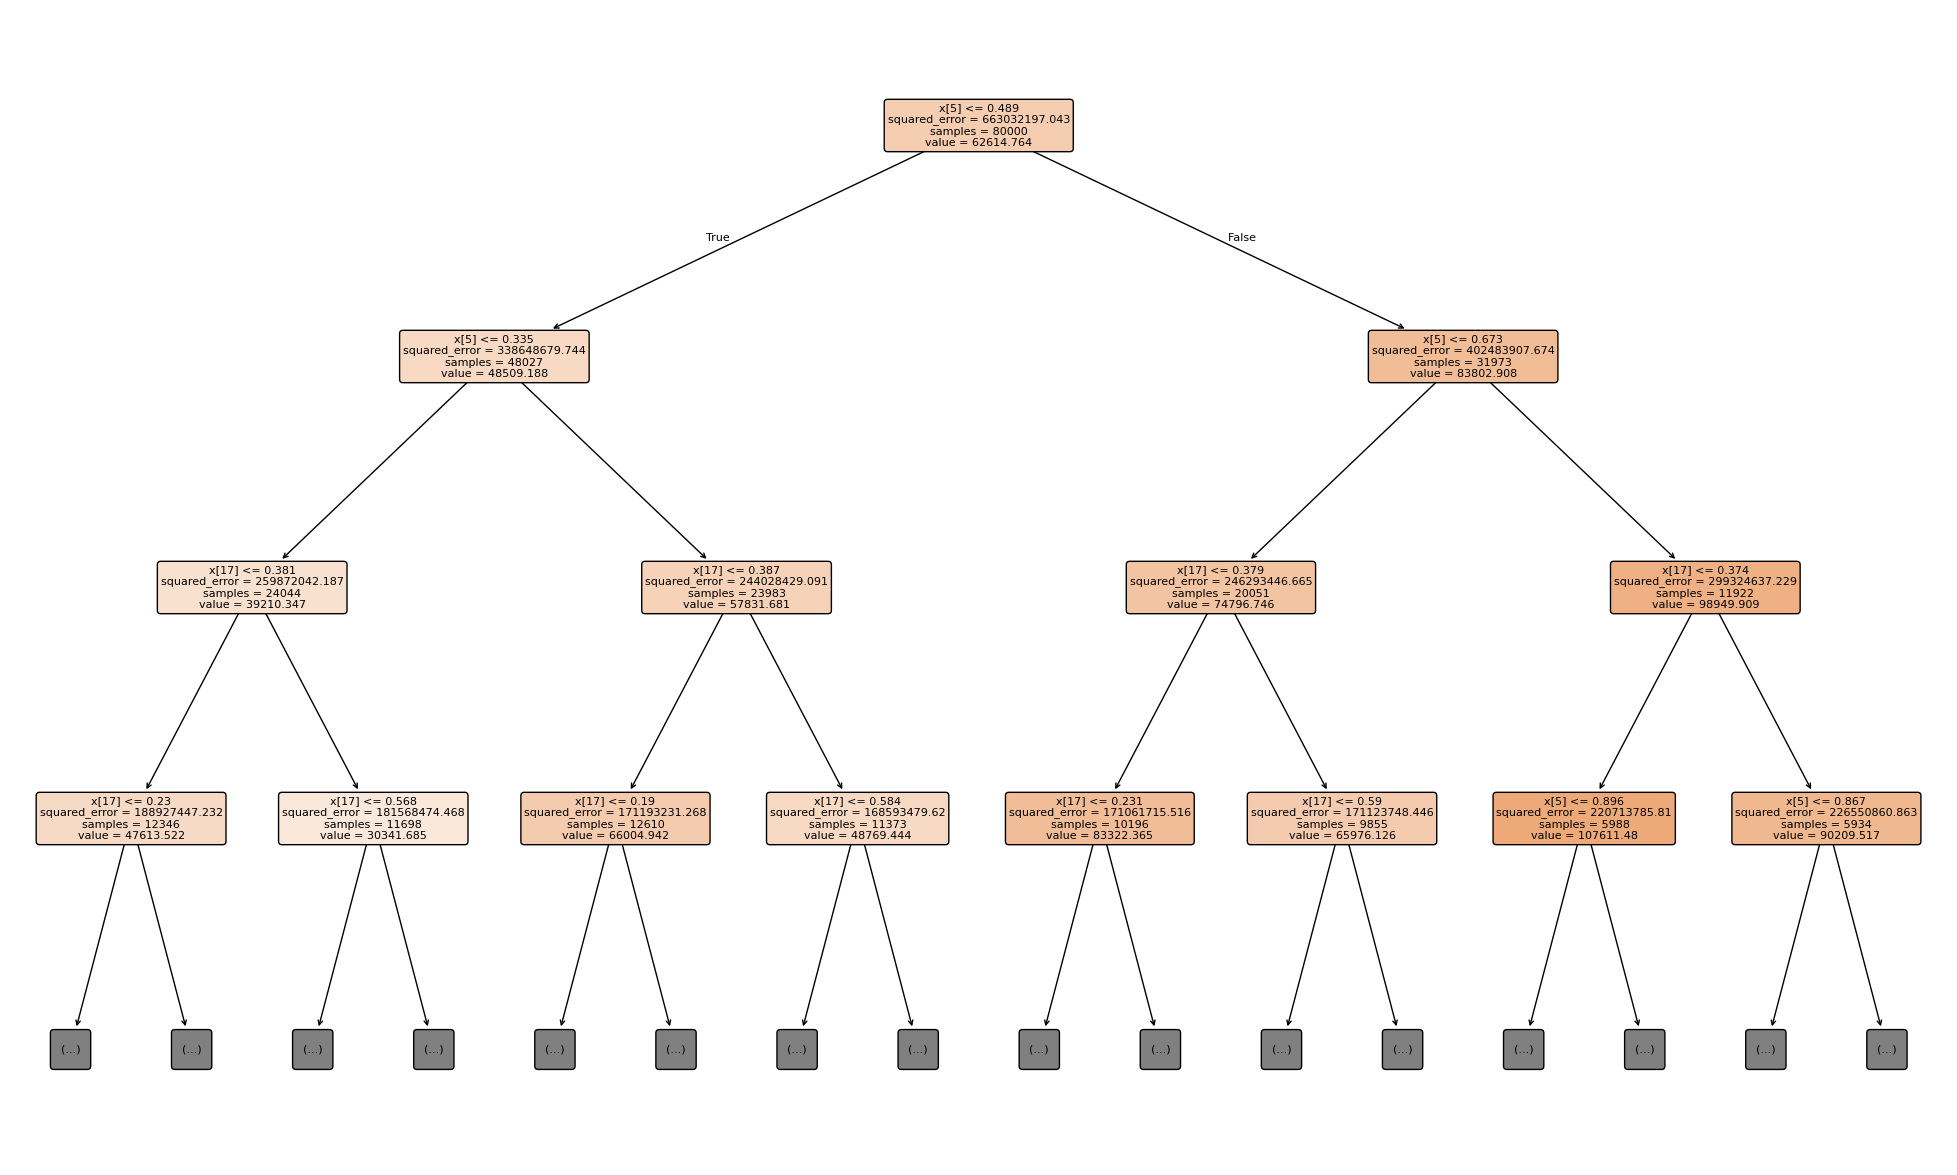

In [61]:
plt.figure(figsize=(25, 15))

tree.plot_tree(
    best_dt,
    filled=True,
    rounded=True,
    fontsize=8,
    max_depth=3
)

plt.savefig("decision_tree.png")
plt.show()